# Hamming's Proof of Noise Growth under Application of the Discrete Derivative

<br>
<br>

<center>
Mauro J. Sanchirico III
<br>
May 7 2026
</center>

<br>
<br>

*This is an educational notebook intended to demonstrate the well-known impacts of discrete derivatives on noisy time series data. Well-known textbook insights from the great Richard Hamming on the exacerbating effect that discrete derivatives have on noisy signals are further exposited with steps expanded and analysis on explicit effects of discrete derivatives on signal to noise ratio (SNR) included. Numerical examples are included to complement the derivations.*

<br>
<br>

---

## 1. Introduction

The discrete derivative, defined here by the forward difference operator,
$$
\Delta f(x) = f(x+h) - f(x),
$$
must be used with caution in algorithm design, due to its well-known tendency to amplify noise. When the discrete derivative is applied to a noisy time series, the noise component of the time series will be amplified, while the signal component will tend towards zero for many practical applications. Consider, for example, a time series which represents the position of an object in the physical world. It is likely that position of the object as a function of time is easily represented as a polynomial over a short time window, and that measuring the position of the object results in a time series that can be represented as a polynomial plus a Gaussian noise term. The discrete derivatives of a polynomial will tend towards zero (as the continuous derivatives will), but as we will see, the Gaussian noise component will be amplified by a factor of
$$
\binom{2k}{k}
=
\frac{(2k)!}{(k!)^2}
$$
where $k$ is the order of the discrete derivative taken.

Here we analyze how signal power is affected by complex and difficult to predict effects, and noise power always increases with respect to the number of discrete derivatives taken of a time series and present numerical examples. While there are a number of ways to approach this analysis, we take a random variable algebra approach, following Hamming's explanation in Chapter 2 of Numerical Methods for Scientists and Engineers. We further exposit Hamming's explanation by starting with specific examples of first and second order differences, and computing the result for a generic function with errors,
$$
f(x) = \varphi(x) + \eta(x),
$$
then computing the power caused by the noise term $\eta(x)$. We assume throughout that the errors are independently sampled from a normal distribution, $\eta(x) \sim \mathcal{N}(\mu,\sigma^2)$, having mean $\mu = \mathbb{E}[\eta(x)]$ and variance $\sigma^2 = \mathrm{Var}[\eta(x)]$. A frequency domain analysis is also  is left to a future exposition.

Note that throughout the analysis, we use the terms "discrete derivative" and "forward difference" interchangeably. Similar analysis could be performed for backwards differences, or for a discrete derivative where we divide by the step size to more closely resemble the continuous derivative, i.e., $\frac{\Delta f}{\Delta x}$. However, as will will see, dividing by the step size has no impact on the noise, since the division by the step size amplifies the signal and noise components equally. Division by the step size is for this reason omitted for simplicity.

### 1.1 Hamming on Discrete Derivatives

Hamming discusses the practical considerations on discrete derivative impacts to noise in a number of his books. *All* are recommended reading, both for exposition of difference calculus and related considerations in digital computing, and for more general engineering wisdom.

Specific references recommended to go along with this memo:

* *Numerical Methods for Scientists and Engineers - Chapter 1 - The Difference Calculus*. See the error propagation table for the difference operator.
* *Numerical Methods for Scientists and Engineers - Chapter 2 - Roundoff Noise*. This is the derivation we follow here for the amount of noise in the $k$th discrete derivative.
* *The Art of Doing Science and Engineering - Chapters 14-17 - Digital Filters I-IV*. See the explanation of the difference operator in the frequency domain in Digital Filters III and the story about noisy data series (and initial resistance to the idea of applying filters to non-time-series data) in Digital Filters IV.

### 1.2 Example Signals

We leverage a noisy sinusoid as an example signal where the signal term is a sinusoid, $\varphi(x)= \sin(x)$ and the error term, $\eta(x)$ is sampled from a normal distribution with zero mean and standard deviation $\sigma = 0.2$. We choose a sinusoid instead of a polynomial so that the signal will not completely disappear as we take higher order discrete derivatives. The theoretical power in our signal is given by the familiar expression for the power of a sinusoid,

$$
P_{\varphi} = \frac{A^2}{2}
$$

The power in the noise is given by the familiar expression for the power in a zero-mean Gaussian noise signal,

$$
P_{\eta} = \sigma^2
$$

We define the signal to noise ratio (SNR) as the total power in the signal divided by the total power in the noise, i.e.,

$$
\begin{align*}
\mathrm{SNR} &= 10 \log_{10} \left(\frac{P_{\varphi}}{P_{\eta}}\right) \\
    &= 10 \log_{10} \left(\frac{\mathbb{E}[\varphi^2(x)]}{\mathbb{E}[\eta^2(x)]} \right) \\
\end{align*}
$$

We see the numerical power values align well with these predictions.

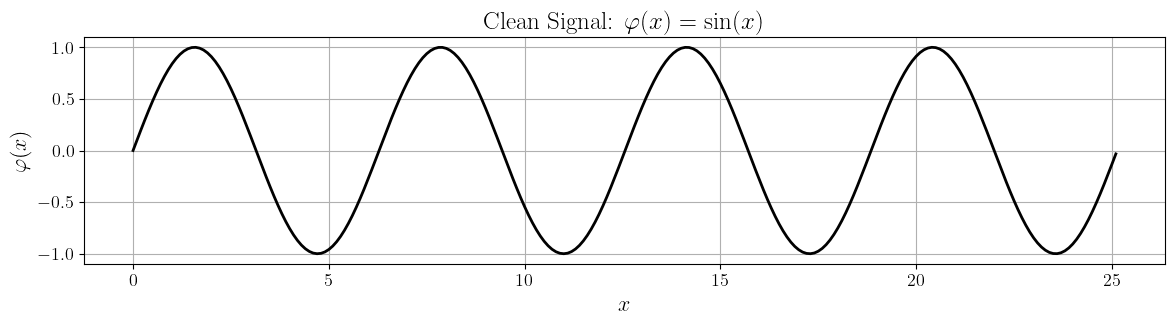

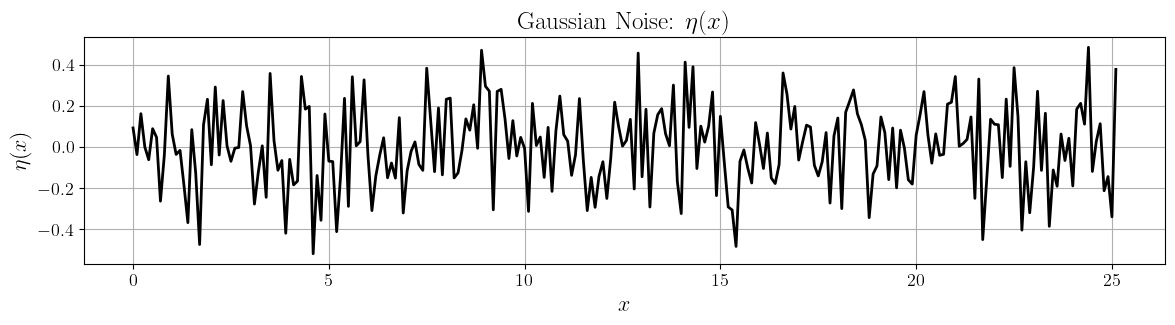

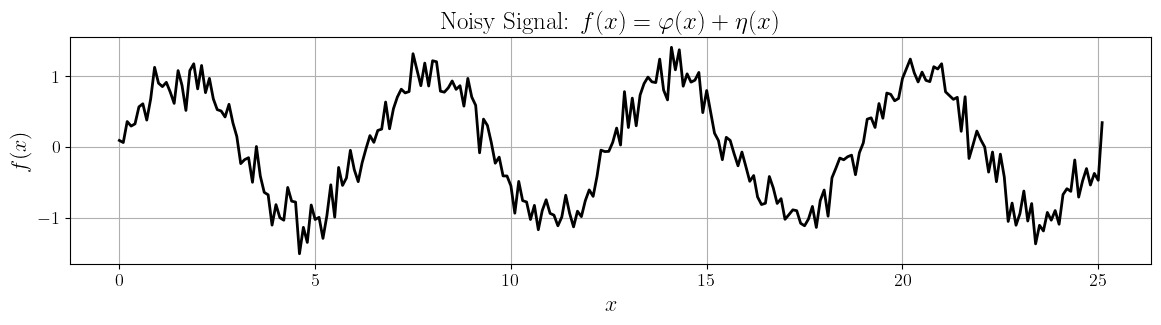

Measured original signal power = 0.498665
Theoretical original signal power = 0.500000

Measured original noise power = 0.039636
Theoretical original noise power = 0.040000

Measured original SNR (dB) = 10.997154
Theoretical original SNR (dB) = 10.969100


In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        'text.usetex': True,
        'font.family': 'serif',
        'font.size': 15,
        'axes.labelsize': 16,
        'axes.titlesize': 18,
        'legend.fontsize': 14,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'figure.figsize': (10, 5),
        'lines.linewidth': 2,
        'axes.grid': True,
    }
)

# Sinusoidal example signal
h = 0.1
x = np.arange(0, 8 * np.pi, h)
N = len(x)
phi = np.sin(x)

# Gaussian noise
mu = 0.0
sigma = 0.2
eta = np.random.normal(mu, sigma, size=N)

# Noisy signal
f = phi + eta

# Plot signal
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x, phi, color='black')
ax.set_title(r'Clean Signal: $\varphi(x) = \sin(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\varphi(x)$')
plt.tight_layout()
plt.show()

# Plot noise
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x, eta, color='black')
ax.set_title(r'Gaussian Noise: $\eta(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\eta(x)$')
plt.tight_layout()
plt.show()

# Plot noisy signal
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x, f, color='black')
ax.set_title(r'Noisy Signal: $f(x)=\varphi(x)+\eta(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$f(x)$')
plt.tight_layout()
plt.show()

# Compute numerical signal and noise power
P_phi_measured = np.mean(phi**2)
P_eta_measured = np.mean(eta**2)
SNR_measured_dB = 10 * np.log10(P_phi_measured / P_eta_measured)

# Compute theoretical signal and noise power
P_phi_theory = 0.5
P_eta_theory = sigma**2
SNR_theory_dB = 10 * np.log10(P_phi_theory / P_eta_theory)

print(f'Measured original signal power = {P_phi_measured:.6f}')
print(f'Theoretical original signal power = {P_phi_theory:.6f}')
print()
print(f'Measured original noise power = {P_eta_measured:.6f}')
print(f'Theoretical original noise power = {P_eta_theory:.6f}')
print()
print(f'Measured original SNR (dB) = {SNR_measured_dB:.6f}')
print(f'Theoretical original SNR (dB) = {SNR_theory_dB:.6f}')

## 2. First Difference Analysis

We start by analyzing the first difference as a special case before proceeding to analyze the second difference and then the general $k^{\mathit{th}}$ difference. We begin by using random variable algebra to compute the result of the first difference of a noisy time series, and then compute the power in the contributions the signal and noise each have on the result respectively to compare against the original power levels and compute the change in SNR induced by the discrete derivative operation.

### 2.1 Random Variable Algebra Inspection of the First Difference

We begin by substituting our noisy time series, $f(x)=\varphi(x)+\eta(x)$, into the first difference equation, $\Delta f(x)=f(x+h)-f(x)$. This gives
$$
\Delta f(x)
=
\left[\varphi(x+h)+\eta(x+h)\right]
-
\left[\varphi(x)+\eta(x)\right].
$$

Manipulating algebraically gives
$$
\Delta f(x)
=
\varphi(x+h)-\varphi(x)
+
\eta(x+h)-\eta(x),
$$
which we can also see from the linearity of the difference operator, i.e., $\Delta (f(x) + g(x)) = \Delta f(x) + \Delta g(x)$, such that we can write
$$
\Delta f(x)
=
\Delta \varphi(x)
+
\Delta \eta(x).
$$

Since $\eta(x+h)$ and $\eta(x)$ are independent Gaussian random variables, $\Delta \eta(x)=\eta(x+h)-\eta(x)$ is also Gaussian with mean $\mathbb{E}[\Delta \eta(x)] = \mu-\mu = 0$, and variance $\mathrm{Var}[\Delta \eta(x)] = \mathrm{Var}[\eta(x+h)] + \mathrm{Var}[\eta(x)] = \sigma^2+\sigma^2 = 2\sigma^2$ such that
$$
\Delta \eta(x)\sim\mathcal{N}(0,2\sigma^2).
$$

Numerically, $\Delta f(x)$ is computed and visualized as follows.

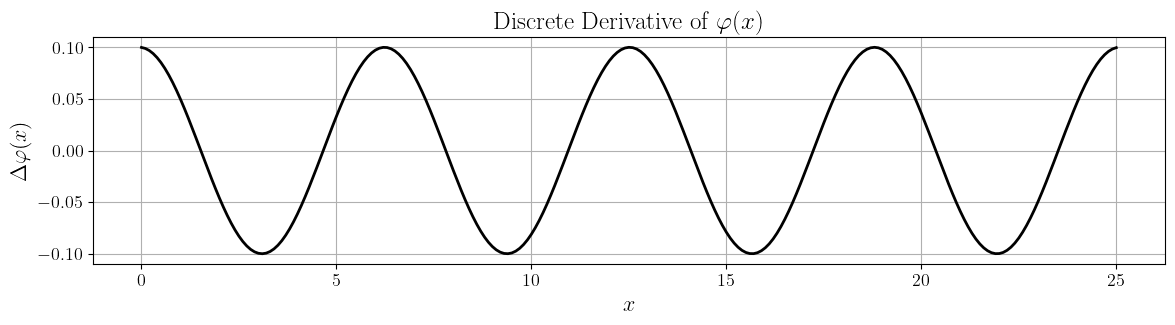

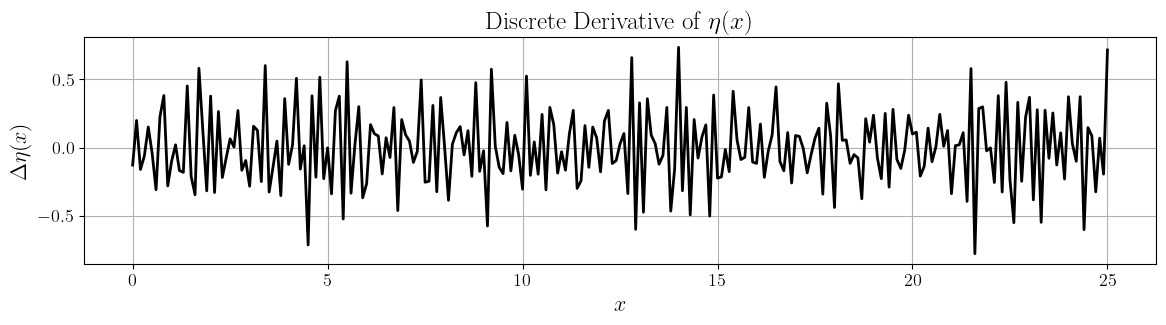

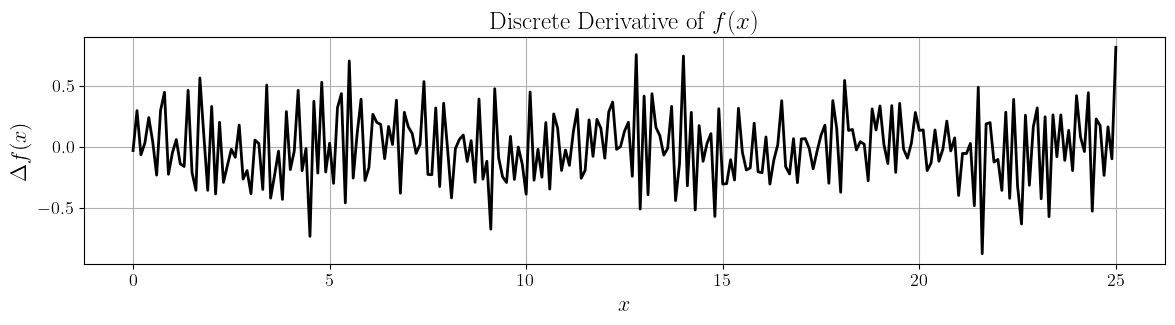

In [33]:
d_phi = np.diff(phi)
d_eta = np.diff(eta)
d_f = np.diff(f)
x_diff = x[:-1]


fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_diff, d_phi, color='black')
ax.set_title(r'Discrete Derivative of $\varphi(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\Delta \varphi(x)$')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_diff, d_eta, color='black')
ax.set_title(r'Discrete Derivative of $\eta(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\Delta \eta(x)$')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_diff, d_f, color='black')
ax.set_title(r'Discrete Derivative of $f(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\Delta f(x)$')
plt.tight_layout()
plt.show()

### 2.2 Signal Power After the First Difference

Notice that the signal's contribution decreased in power and the noise increased in power! Two effects are at work here. First, *discrete calculus rules will cause the power in the signal to decrease*, and meanwhile *addition of the noise distributions from adjacent samples will cause the variance of the noise to spread*, increasing the noise power. We could handle the decrease in power of the signal by multiplying by some factor to account for it, but since we do not have any idea what the true form of the signal is in practical applications (and therefore cannot extract it from the noise before further manipulations) we must multiply $\Delta f(x)$ by our factor, which would also multiple $\eta(x)$ by the factor and do nothing to change the SNR!

To see the reduction in power of the signal's contributions, note discrete calculus rules are related (but not one-to-one equivalent to) continuous calculus rules. While the continuous derivative rule for $\sin(x)$ is the familiar $\frac{\partial}{\partial x} \sin(ax + b) = a\cos(ax + b)$, the discrete derivative rule for $\sin(x)$ is
$$
\Delta \sin(ax + b) = 2 \sin\left(\frac{ah}{2}\right) \cos\left[ a\left(x+\frac{h}{2}\right)+ b\right],
$$
where $h$ is the step size. We can see how this converges to the familiar continuous rule in the limit as $h \to 0$ since we often take approximate derivatives (noted here as $\tilde{D}$) as
$$
\tilde{D_x} f(x) = \frac{\Delta f(x)}{\Delta x}
$$
which simplifies to
$$
\tilde{D_x} f(x) = \frac{\Delta f(x)}{h}
$$
for uniformly sampled $x$. Taking the limit,

$$
\lim_{h \to 0} \tilde{D_x} \sin(ax + b) = \lim_{h \to 0} \left( 2 \frac{\sin\left(\frac{ah}{2}\right)}{h} \cos\left( a\left(x+\frac{h}{2}\right)+ b\right) \right),
$$
and recognizing the limit of the sinc function,
$$
\lim_{h \to 0} \frac{2 \sin\left(\frac{ah}{2}\right)}{h} = a,
$$
reveals the familiar continuous rule since the amplitude reduces to $a$ and the phase shift, $\frac{ah}{2}$, reduces to $0$.

With no division by $h$, the power in the signal after the first discrete derivative is given by

$$
\begin{align*}
P_{\Delta \varphi} &= \mathbb{E}[\varphi^2(x)] \\
    &= \frac{A^2}{2}
\end{align*}
$$

where $A = 2 \sin\left(\frac{ah}{2}\right)$ such that

$$
\begin{align*}
P_{\Delta \varphi} &= \frac{2^2 \sin^2 \left(\frac{ah}{2}\right)}{2} \\
    &= 2 \sin^2 \left(\frac{ah}{2}\right).
\end{align*}
$$

Since $a = 1$ in this case we have

$$
P_{\Delta \varphi} = 2 \sin^2 \left(\frac{h}{2}\right).
$$

In [34]:
# Numerically compute power after the discrete derivative
P_d_phi_measured = np.mean(d_phi**2)

# Compute power using the equation
P_d_phi_theory = 2 * np.sin(h / 2) ** 2

print(
    f'Measured signal power after discrete derivative = {P_d_phi_measured:.6f}'
)
print(
    f'Theoretical signal power after discrete derivative = {P_d_phi_theory:.6f}'
)

Measured signal power after discrete derivative = 0.004989
Theoretical signal power after discrete derivative = 0.004996


### 2.3 Noise Power After First Difference

Now we compute the power of the noise after the discrete derivative to see the effect that the discrete derivative had on the noise. For a random variable $X$, its power is given by $P_X = \mathbb{E}[X^2]$. The power of $X\sim\mathcal{N}(\mu,\sigma^2)$ is given by $P_X=\sigma^2+\mu^2$ such that
$$
P_\eta=\sigma^2
$$
and
$$
P_{\Delta \eta}=2\sigma^2.
$$

The ratio of noise power after the discrete derivative is taken to original noise power is then given by
$$
\frac{P_{\Delta \eta}}{P_\eta}
=
\frac{2\sigma^2}{\sigma^2}
=
2.
$$

Checking against the original formula, this matches the expected result, since
$$
\frac{(2 \times 1)!}{(1!)^2} = 2.
$$

In [35]:
# Numerically compute power after the discrete derivative
P_d_eta_measured = np.mean(d_eta**2)

# Compute power using the equation
P_d_eta_theory = 2 * P_eta_theory

print(
    f'Measured noise power after discrete derivative = {P_d_eta_measured:.6f}'
)
print(
    f'Theoretical noise power after discrete derivative = {P_d_eta_theory:.6f}'
)

Measured noise power after discrete derivative = 0.078227
Theoretical noise power after discrete derivative = 0.080000


### 2.4 Change in SNR After First Difference

Now we can compute how the first difference degraded the SNR of the signal. The original SNR is given as

$$
\begin{align*}
SNR &= 10 \log_{10} \left(\frac{P_{\varphi}}{P_{\eta}} \right) \\
    &= 10 \log_{10} \left(\frac{1}{2\sigma^2} \right) \\
\end{align*}
$$

while the new SNR after the first discrete derivative, which we denote $SNR|_\Delta$ is given as

$$
\begin{align*}
SNR|_\Delta &= 10 \log_{10} \left( \frac{P_{\Delta \varphi}}{P_{\Delta \eta}} \right) \\
    &= 10 \log_{10} \left( \frac{2 \sin^2 \left(\frac{h}{2}\right)}{2 \sigma^2} \right) \\
    &= 10 \log_{10} \left( \frac{\sin^2 \left(\frac{h}{2}\right)}{\sigma^2} \right) \\
\end{align*}
$$

The SNR gained (in practice, the SNR lost) due to the first difference, which we denote $G|_\Delta$, is given by taking the difference in SNR yielded by the application of the discrete derivative and applying logarithm identities:

$$
\begin{align*}
G|_\Delta &= SNR|_\Delta - SNR \\
    &= 10 \log_{10} \left( \frac{P_{\Delta \varphi}}{P_{\Delta \eta}} \right) - 10 \log_{10} \left(\frac{P_{\varphi}}{P_{\eta}} \right) \\
    &= 10 \log_{10} \left(\frac{2 \sigma^2 \sin^2\left(\frac{h}{2}\right)}{ \sigma^2 } \right).
\end{align*}
$$

Simplifying yields the expression for the gain or loss due to the discrete derivative,

$$
G_\Delta = 10 \log_{10} \left( 2 \sin^2 \left( \frac{h}{2} \right) \right).
$$

We note that the gain or loss depends on the step size, $h$. Given $\omega = 1$, we know that $f = \frac{1}{2 \pi}$ so the Nyquist sampling frequency is $f_N = \frac{1}{\pi}$ and the corresponding Nyquist sampling period is $h_N = \pi$.

We could attempt to sample at Nyquist, which *could* in theory incur a positive gain of $G|_\Delta = 10 \log_{10} \left( 2 \sin^2\left( \frac{\pi}{2} \right) \right) \approx 3\ \mathrm{dB}$. In practice, however, since we do not know the timing of the signal, the samples may be aligned with the zeros of the signal, rather than its peaks, which would result in a sampling loss that would cancel any benefit of Nyquist sampling. Further, a practical signal would likely include multiple frequency components with the Nyquist frequency being twice the highest frequency, and lower frequency components would still include a loss on application of the discrete derivative. Sampling at twice Nyquist, i.e., $h = \frac{\pi}{2}$ could, with perfect alignment, cancel losses to exactly $0\ \mathrm{dB}$, however, lower frequency components would still incur losses

With all effects considered, a first difference will, for a noisy sinusoid:

* Double the power of the noise
* Have a difficult to predict effect on the signal which is dependent on the alignment of samples to the signal's peaks (a usually unknown effect) and dependent on the relationship between the signal's frequency content and the sample spacing
* For practical sampling (above twice the Nyquist frequency), incur a *guaranteed loss* on all frequency components below the highest frequency in the signal!

Counter-intuitively, over-sampling significantly exacerbates the effect. So, the optimal sampling (if there are plans to *attempt* a discrete derivative) is a trade off between sampling enough above Nyquist to prevent sample alignment with signal zeros from incurring a sampling loss, and avoiding oversampling to such a degree that difference loss becomes unmanageable. While there may be some applications where an optimal sampling frequency can be identified and these effects can be made manageable, clearly in most practical applications where signal content is unknown or comprised of multiple frequencies, and even small amounts of noise are present, a discrete derivative is a gamble on SNR budget at best, and will incur significant losses in the worst case!

In [36]:
# Measured SNR after first difference
SNR1_measured = P_d_phi_measured / P_d_eta_measured
SNR1_measured_dB = 10 * np.log10(SNR1_measured)

# Theoretical SNR after first difference
SNR1_theory = (np.sin(h / 2) ** 2) / sigma**2
SNR1_theory_dB = 10 * np.log10(SNR1_theory)

# Change in SNR
delta_SNR_measured_dB = SNR1_measured_dB - SNR_measured_dB
delta_SNR_theory_dB = 10 * np.log10(2 * np.sin(h / 2) ** 2)

# Print results
print('SNR after first difference')
print(f'Measured SNR (dB) = {SNR1_measured_dB:.2f} dB')
print(f'Theoretical SNR (dB) = {SNR1_theory_dB:.2f} dB')

print()

print('Change in SNR due to first difference')
print(f'Measured Gain (dB) = {delta_SNR_measured_dB:.2f} dB')
print(f'Theoretical Gain (dB) = {delta_SNR_theory_dB:.2f} dB')

SNR after first difference
Measured SNR (dB) = -11.95 dB
Theoretical SNR (dB) = -12.04 dB

Change in SNR due to first difference
Measured Gain (dB) = -22.95 dB
Theoretical Gain (dB) = -23.01 dB


## 3. Second Difference

### 3.1 Random Variable Algebra Inspection of the Second Difference

The second forward difference is $\Delta^2 f(x) = \Delta(\Delta f(x)).$ Reapplying the definition of the forward difference, $\Delta f(x)=f(x+h)-f(x)$, yields
$$
\Delta^2 f(x) = \left[f(x+2h)-f(x+h)\right] - \left[f(x+h)-f(x)\right].
$$

Combining terms yields the second difference equation
$$
\Delta^2 f(x) = f(x+2h)-2f(x+h)+f(x).
$$

Substituting in our noisy signal, $f(x)=\varphi(x)+\eta(x)$, yields
$$
\Delta^2 f(x) = \left[\varphi(x+2h)+\eta(x+2h)\right] - 2\left[\varphi(x+h)+\eta(x+h)\right] + \left[\varphi(x)+\eta(x)\right].
$$

Simplifying algebraically yields
$$
\Delta^2 f(x) = \varphi(x+2h)-2\varphi(x+h)+\varphi(x) + \eta(x+2h)-2\eta(x+h)+\eta(x),
$$

which again follows naturally from the linearity of the difference operator such that
$$
\Delta^2 f(x) = \Delta^2 \varphi(x) + \Delta^2 \eta(x).
$$

Numerically, $\Delta^2 f(x)$ is computed and visualized as follows.


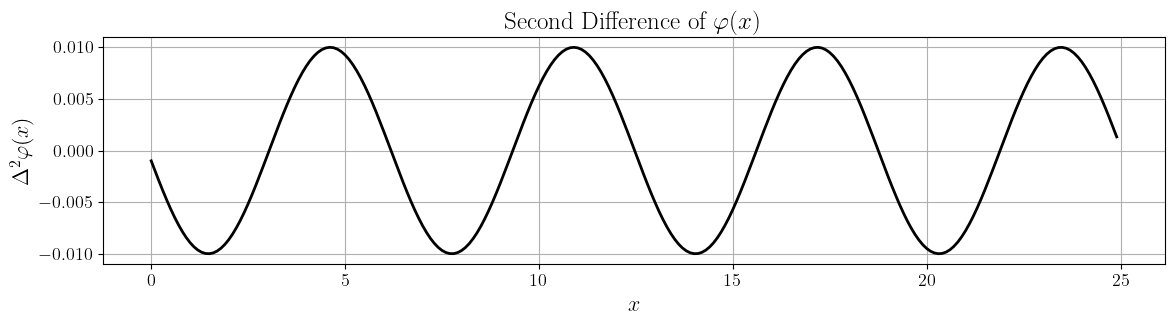

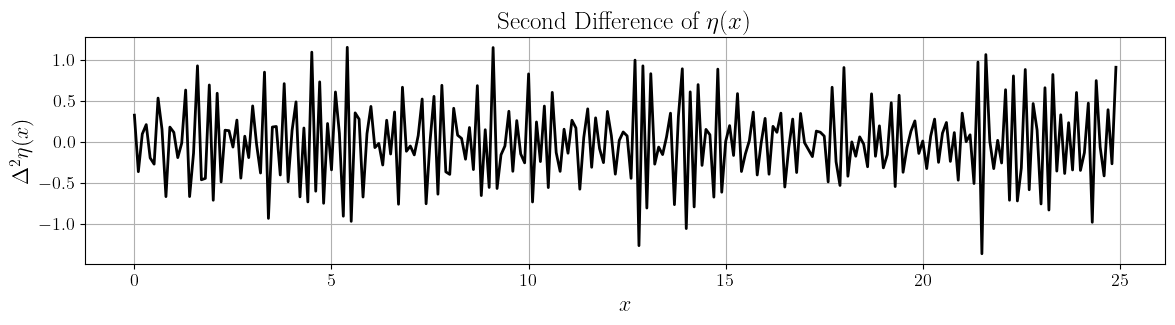

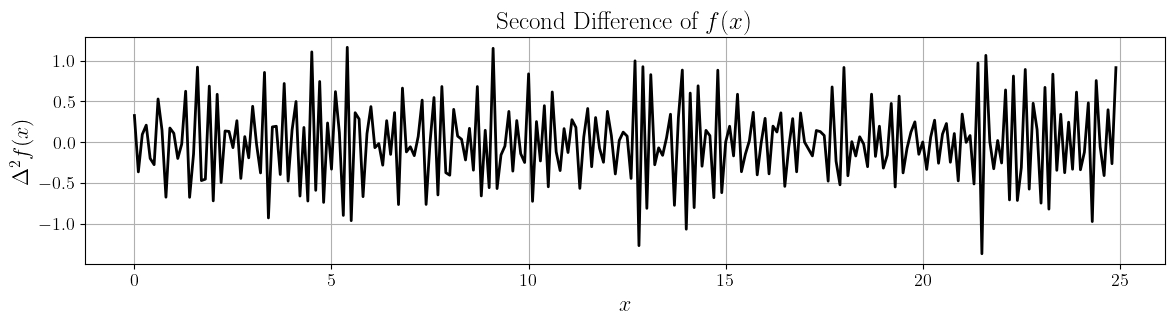

In [37]:
d2_phi = np.diff(phi, n=2)
d2_eta = np.diff(eta, n=2)
d2_f = np.diff(f, n=2)
x_diff2 = x[:-2]

# Plot second difference of the clean signal
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_diff2, d2_phi, color='black')
ax.set_title(r'Second Difference of $\varphi(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\Delta^2 \varphi(x)$')
plt.tight_layout()
plt.show()

# Plot second difference of the noise
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_diff2, d2_eta, color='black')
ax.set_title(r'Second Difference of $\eta(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\Delta^2 \eta(x)$')
plt.tight_layout()
plt.show()

# Plot second difference of the noisy signal
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_diff2, d2_f, color='black')
ax.set_title(r'Second Difference of $f(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\Delta^2 f(x)$')
plt.tight_layout()
plt.show()

### 3.2 Signal Power After the Second Difference

We see that the noise continues to grow and the signal continues to shrink in power! The second finite difference of our sinusoid is given by the rule
$$
\Delta^2 \sin(ax+b)
=
-4
\sin^2\left(\frac{ah}{2}\right)
\sin(ax+ah+b).
$$

Noting that the sinusoid amplitude is $A = 4\sin^2\left(\frac{ah}{2}\right)$ and again applying $P=\frac{A^2}{2}$ yields
$$
P_{\Delta^2 \varphi} =
\frac{
\left(
4\sin^2\left(\frac{ah}{2}\right)
\right)^2
}{2}.
$$

Simplifying and noting $a = 1$ yields

$$
P_{\Delta^2 \varphi}
=
8\sin^4\left(\frac{h}{2}\right).
$$


In [38]:
# Measured power in the second difference of the signal
P_d2_phi_measured = np.mean(d2_phi**2)

# Theoretical power in the second difference of the signal
P_d2_phi_theory = 8 * np.sin(h / 2) ** 4

print(f'Measured second difference signal power = {P_d2_phi_measured:.6e}')
print(f'Theoretical second difference signal power = {P_d2_phi_theory:.6e}')

Measured second difference signal power = 5.018129e-05
Theoretical second difference signal power = 4.991673e-05


### 3.3 Noise Power After the Second Difference

Given our assumptions that all $\eta$ samples are independent and Gaussian, we know that $\Delta^2 \eta(x) = \eta(x+2h)-2\eta(x+h)+\eta(x)$ is also Gaussian with mean $\mathbb{E}[\Delta^2 \eta(x)] = \mu-2\mu+\mu = 0$ and variance $\mathrm{Var}[\Delta^2 \eta(x)] = \sigma^2 + (-2)^2\sigma^2 + \sigma^2 = \sigma^2+4\sigma^2+\sigma^2 = 6\sigma^2$, such that
$$
\Delta^2 \eta(x)
\sim
\mathcal{N}(0,6\sigma^2).
$$

The power is computed trivially therefrom:

$$
P_{\Delta^2 \eta}=6\sigma^2.
$$

Therefore,

$$
\frac{P_{\Delta^2 \eta}}{P_\eta} = \frac{6\sigma^2}{\sigma^2} = 6.
$$

So, we see the second difference increases the noise power by a factor of $6$.

In [39]:
# Measured power in the second difference of the noise
P_d2_eta_measured = np.mean(d2_eta**2)

# Theoretical power in the second difference of the noise
P_d2_eta_theory = 6 * sigma**2

print(f'Measured second difference noise power = {P_d2_eta_measured:.6e}')
print(f'Theoretical second difference noise power = {P_d2_eta_theory:.6e}')

Measured second difference noise power = 2.373500e-01
Theoretical second difference noise power = 2.400000e-01


### 3.4 Change in SNR After Second Difference

Now we can compute how the second difference degraded the SNR of the signal. The original SNR is given as
$$
\begin{align*}
SNR &= 10 \log_{10} \left(\frac{P_{\varphi}}{P_{\eta}} \right) \\
    &= 10 \log_{10} \left(\frac{1}{2\sigma^2} \right).
\end{align*}
$$


The new SNR after the second discrete derivative, which we denote, $SNR|_{\Delta^2}$, is given as
$$
\begin{align*}
SNR|_{\Delta^2}
    &= 10 \log_{10} \left( \frac{P_{\Delta^2 \varphi}}{P_{\Delta^2 \eta}} \right) \\
    &= 10 \log_{10} \left(
        \frac{
            8 \sin^4 \left(\frac{h}{2}\right)
        }{
            6\sigma^2
        }
    \right) \\
    &= 10 \log_{10} \left(
        \frac{
            4 \sin^4 \left(\frac{h}{2}\right)
        }{
            3\sigma^2
        }
    \right).
\end{align*}
$$

The SNR gained, or in practice lost, due to the second difference, which we denote $G|_{\Delta^2}$ is again given by taking the difference in SNR yielded by the application of the second discrete derivative and applying logarithm identities:
$$
\begin{align*}
G|_{\Delta^2}
    &= SNR|_{\Delta^2} - SNR \\
    &= 10 \log_{10} \left( \frac{P_{\Delta^2 \varphi}}{P_{\Delta^2 \eta}} \right)
       - 10 \log_{10} \left(\frac{P_{\varphi}}{P_{\eta}} \right) \\
    &= 10 \log_{10} \left(
        \frac{
            \frac{8 \sin^4 \left(\frac{h}{2}\right)}{6\sigma^2}
        }{
            \frac{1}{2\sigma^2}
        }
    \right) \\
    &= 10 \log_{10} \left(
        \frac{
            16\sigma^2 \sin^4 \left(\frac{h}{2}\right)
        }{
            6\sigma^2
        }
    \right) \\
    &= 10 \log_{10} \left(
        \frac{8}{3}
        \sin^4 \left(\frac{h}{2}\right)
    \right).
\end{align*}
$$

So the gain or loss due to the second discrete derivative is
$$
G|_{\Delta^2}
=
10 \log_{10}
\left(
\frac{8}{3}
\sin^4 \left( \frac{h}{2} \right)
\right).
$$

In [ ]:
# Measured SNR after second difference
SNR2_measured = P_d2_phi_measured / P_d2_eta_measured
SNR2_measured_dB = 10 * np.log10(SNR2_measured)

# Theoretical SNR after second difference
SNR2_theory = (4 * np.sin(h / 2) ** 4) / (3 * sigma**2)
SNR2_theory_dB = 10 * np.log10(SNR2_theory)

# Change in SNR
delta_SNR2_measured_dB = SNR2_measured_dB - SNR_measured_dB
delta_SNR2_theory_dB = 10 * np.log10((8 / 3) * np.sin(h / 2) ** 4)

# Print results
print('SNR after second difference')
print(f'Measured SNR (dB) = {SNR2_measured_dB:.2f} dB')
print(f'Theoretical SNR (dB) = {SNR2_theory_dB:.2f} dB')

print()

print('Change in SNR due to second difference')
print(f'Measured Gain (dB) = {delta_SNR2_measured_dB:.2f} dB')
print(f'Theoretical Gain (dB) = {delta_SNR2_theory_dB:.2f} dB')

SNR after second difference
Measured SNR (dB) = -36.75 dB
Theoretical SNR (dB) = -36.82 dB

Change in SNR due to second difference
Measured Gain (dB) = -47.75 dB
Theoretical Gain (dB) = -47.79 dB


### 3.5 Check Against the Combinatorial Formula

The original combinatorial formula for the noise amplification factor is $\binom{2k}{k} = \frac{(2k)!}{(k!)^2}$. Before proceeding to analyze the general case, we check the result obtained for the second difference against this formula. For the first difference, $k=1$ $\binom{2}{1}=2$ and $\frac{P_{\Delta \eta}}{P_\eta}=2$. For the second difference, $k=2$, $\binom{4}{2} = \frac{4!}{2!^2} = \frac{24}{4} = 6$, which matches the expected result.


# The $k$-th Difference

The $k$-th forward difference is

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
f(x+nh).
$$

Writing the binomial coefficient explicitly,

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\frac{k!}{n!(k-n)!}
f(x+nh).
$$

Substitute

$$
f(x)=\varphi(x)+\eta(x)
$$

into the $k$-th difference:

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\left[
\varphi(x+nh)+\eta(x+nh)
\right].
$$

Distribute the sum:

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\varphi(x+nh)
+
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\eta(x+nh).
$$

Define

$$
\Delta^k \eta(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\eta(x+nh).
$$

Then

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\varphi(x+nh)
+
\Delta^k \eta(x).
$$

Assume

$$
\eta(x), \eta(x+h), \eta(x+2h), \dots, \eta(x+kh)
$$

are independent Gaussian random variables with distribution

$$
\mathcal{N}(\mu,\sigma^2).
$$

Then $\Delta^k \eta(x)$ is Gaussian.

The mean is

$$
\mathbb{E}[\Delta^k \eta(x)]
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\mu.
$$

Factor out $\mu$:

$$
\mathbb{E}[\Delta^k \eta(x)]
=
\mu
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}.
$$

Using the binomial identity

$$
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
=
0,
\qquad k\ge 1,
$$

we get

$$
\mathbb{E}[\Delta^k \eta(x)] = 0.
$$

Now compute the variance:

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sum_{n=0}^{k}
\left[
(-1)^{k-n}
\binom{k}{n}
\right]^2
\sigma^2.
$$

Factor out $\sigma^2$:

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sigma^2
\sum_{n=0}^{k}
\left[
(-1)^{k-n}
\binom{k}{n}
\right]^2.
$$

Since the sign squares away,

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sigma^2
\sum_{n=0}^{k}
\binom{k}{n}^2.
$$

Use the identity

$$
\sum_{n=0}^{k}
\binom{k}{n}^2
=
\binom{2k}{k}.
$$

Therefore,

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sigma^2
\binom{2k}{k}.
$$

So

$$
\Delta^k \eta(x)
\sim
\mathcal{N}
\left(
0,
\sigma^2\binom{2k}{k}
\right),
\qquad k\ge 1.
$$


# Power Ratio for the $k$-th Difference

Since

$$
\Delta^k \eta(x)
\sim
\mathcal{N}
\left(
0,
\sigma^2\binom{2k}{k}
\right),
$$

the power in the $k$-th difference noise is

$$
P_{\Delta^k \eta}
=
\sigma^2\binom{2k}{k}.
$$

The original noise power is

$$
P_\eta=\sigma^2+\mu^2.
$$

Therefore,

$$
\frac{P_{\Delta^k \eta}}{P_\eta}
=
\frac{
\sigma^2\binom{2k}{k}
}{
\sigma^2+\mu^2
}.
$$

For zero-mean noise $(\mu=0)$,

$$
\frac{P_{\Delta^k \eta}}{P_\eta}
=
\frac{
\sigma^2\binom{2k}{k}
}{
\sigma^2
}
=
\binom{2k}{k}.
$$

Using the explicit form of the binomial coefficient,

$$
\frac{P_{\Delta^k \eta}}{P_\eta}
=
\frac{(2k)!}{(k!)^2}.
$$

Thus the noise amplification factor for the $k$-th difference is

$$
\boxed{
\binom{2k}{k}
=
\frac{(2k)!}{(k!)^2}
}
$$

for zero-mean independent Gaussian noise.